# Car Price Predictor

## Download the Data

In [13]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\vibha\.cache\kagglehub\datasets\nehalbirla\vehicle-dataset-from-cardekho\versions\4


In [14]:
import pandas as pd
from pathlib import Path
cars_full = pd.read_csv(Path(path + "\\CAR DETAILS FROM CAR DEKHO.csv"))

## Take a quick look at the data structure

In [15]:
cars_full.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [16]:
cars_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


In [17]:
print(cars_full["name"].value_counts())

name
Maruti Swift Dzire VDI                          69
Maruti Alto 800 LXI                             59
Maruti Alto LXi                                 47
Hyundai EON Era Plus                            35
Maruti Alto LX                                  35
                                                ..
Maruti Swift LDI                                 1
Tata Nano XM                                     1
Mahindra Verito 1.5 D6 BSIII                     1
Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV     1
Hyundai i20 Magna 1.4 CRDi                       1
Name: count, Length: 1491, dtype: int64


In [18]:
cars_full["fuel"].value_counts()

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64

In [19]:
cars_full["seller_type"].value_counts()

seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64

In [20]:
cars_full["transmission"].value_counts()

transmission
Manual       3892
Automatic     448
Name: count, dtype: int64

In [21]:
cars_full["owner"].value_counts()

owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64

In [22]:
cars_full.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


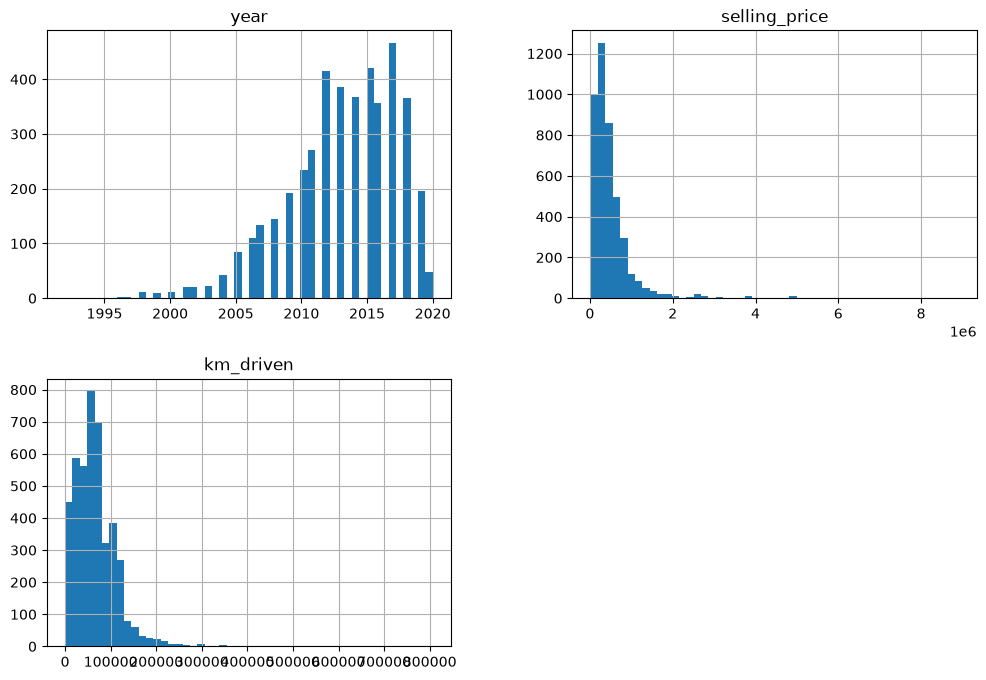

In [23]:
import matplotlib.pyplot as plt

cars_full.hist(bins=50, figsize=(12, 8))
plt.show()

## Create a Test set

In [24]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(cars_full, test_size=0.2,
                                       random_state=42)

## Explore and Visualize the Data to Gain Insights

In [25]:
cars = train_set.copy()

### Look for correlations

In [26]:
corr_matrix = cars.corr(numeric_only=True)

In [27]:
corr_matrix["selling_price"].sort_values(ascending=False)

selling_price    1.000000
year             0.416056
km_driven       -0.189673
Name: selling_price, dtype: float64

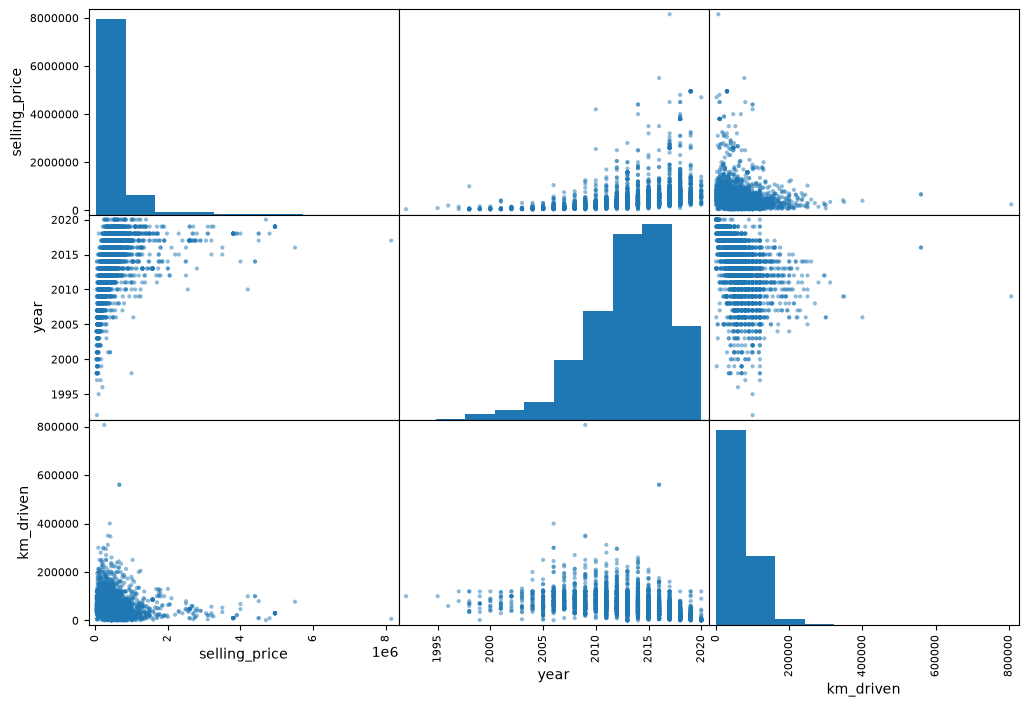

In [28]:
from pandas.plotting import scatter_matrix

attributes = ["selling_price", "year", "km_driven"]

scatter_matrix(cars[attributes], figsize=(12, 8))
plt.show()

## Prepare the Data for Machine Learning Algorithms

In [29]:
cars = train_set.drop("selling_price", axis=1)
cars_labels = train_set["selling_price"].copy()

### Handling text attributes

### Feature Scaling and Transformation

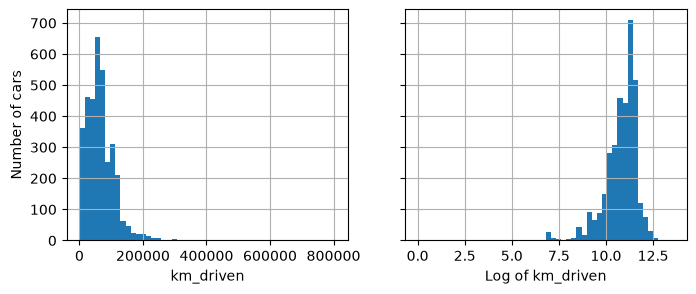

In [30]:
import numpy as np
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
cars["km_driven"].hist(ax=axs[0], bins=50)
cars["km_driven"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("km_driven")
axs[1].set_xlabel("Log of km_driven")
axs[0].set_ylabel("Number of cars")

plt.show()

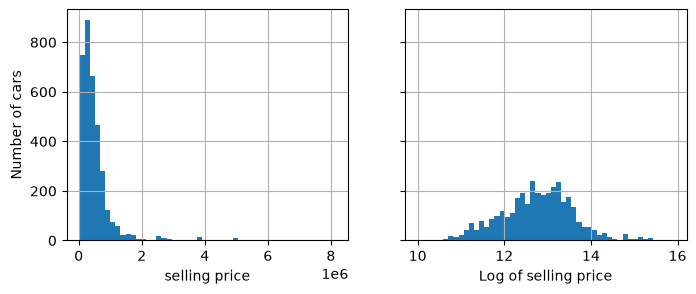

In [31]:
import numpy as np
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
cars_labels.hist(ax=axs[0], bins=50)
cars_labels.apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("selling price")
axs[1].set_xlabel("Log of selling price")
axs[0].set_ylabel("Number of cars")

plt.show()

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

cat_pipeline = make_pipeline(
    OneHotEncoder(handle_unknown="ignore"))
log_pipeline = make_pipeline(
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())
default_num_pipeline = make_pipeline(StandardScaler())
preprocessing = ColumnTransformer([
    ("log", log_pipeline, ["km_driven"]),
    ("cat", cat_pipeline, make_column_selector(dtype_include=str))
    ],
    remainder=default_num_pipeline)                              

In [33]:
cars_prepared = preprocessing.fit_transform(cars)

In [34]:
cars_prepared.shape

(3472, 1340)

In [35]:
preprocessing.get_feature_names_out()

array(['log__km_driven', 'cat__name_Ambassador CLASSIC 1500 DSL AC',
       'cat__name_Ambassador Classic 2000 Dsz', ...,
       'cat__owner_Test Drive Car', 'cat__owner_Third Owner',
       'remainder__year'], shape=(1340,), dtype=object)

## Select and Train a Model

### Train and Evaluate on the Training Set

In [36]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())

In [37]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(
    regressor=lin_reg,
    func=np.log1p,
    inverse_func=np.expm1
)

In [38]:
model.fit(cars, cars_labels)
cars_predictions = model.predict(cars)
cars_predictions[:5].round(-2)

array([1360500.,  581800.,  171700.,  145500.,  685000.])

In [39]:
cars_labels[:5].values

array([1500000,  500000,   92800,   95000,  685000])

In [40]:
from sklearn.metrics import root_mean_squared_error
lin_rmse = root_mean_squared_error(cars_labels, cars_predictions)
lin_rmse

68010.6735640789

In [41]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))

from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(
    regressor=tree_reg,
    func=np.log1p,
    inverse_func=np.expm1
)
model.fit(cars, cars_labels)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...m_state=42))])
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['name','year','km_driven',...,'seller_type','transmission','owner']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,7
regressor_ regressor_: objectFitted regressor.,Pipeline,Pipeline(step...m_state=42))])
transformer_ transformer_: objectTransformer used in :meth:`fit` and :meth:`predict`.,FunctionTransformer,FunctionTrans...validate=True)
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('decisiontreeregressor', ...)]"


In [42]:
cars_predictions = model.predict(cars)
tree_rmse = root_mean_squared_error(cars_labels, cars_predictions)
tree_rmse

5579.363185088404

### Evaluation using Cross-Validation

In [43]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(model, cars, cars_labels,
                              scoring="neg_root_mean_squared_error", cv=10)

In [44]:
pd.Series(tree_rmses).describe()

count        10.000000
mean     322555.455339
std       76053.581892
min      214092.757426
25%      278119.758095
50%      320360.569455
75%      364534.442131
max      446259.917597
dtype: float64

In [45]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing,
                           RandomForestRegressor(random_state=42))

from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(
    regressor=forest_reg,
    func=np.log1p,
    inverse_func=np.expm1
)
forest_rmses = -cross_val_score(model, cars, cars_labels,
                                scoring="neg_root_mean_squared_error", cv=10)

In [46]:
pd.Series(forest_rmses).describe()

count        10.000000
mean     281410.601659
std       65791.633125
min      195937.967266
25%      235360.338447
50%      274161.235719
75%      322711.643622
max      407397.789813
dtype: float64

## Fine Tune your Model

### Grid Search

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])

model = TransformedTargetRegressor(
    regressor=full_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)
param_grid = [
    {'regressor__random_forest__max_features': [4, 6, 8, 10]},
]
grid_search = GridSearchCV(model, param_grid, cv=10,
                           scoring='neg_root_mean_squared_error')
grid_search.fit(cars, cars_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",TransformedTa..._state=42))]))
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'regressor__random_forest__max_features': [4, 6, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the 

In [48]:
grid_search.best_params_

{'regressor__random_forest__max_features': 6}

In [49]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_regressor__random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
1,3.395952,0.178359,0.033599,0.009858,6,{'regressor__random_forest__max_features': 6},-295955.284103,-222596.245900,-196856.858865,-264627.338569,-325763.284227,-329264.045338,-188306.293402,-273875.968015,-451930.390009,-213530.460070,-276270.616850,75831.723188,1
0,3.657457,0.188331,0.038210,0.004506,4,{'regressor__random_forest__max_features': 4},-295366.200704,-229402.132541,-207674.912810,-259311.212182,-318582.667425,-318251.456779,-183940.260900,-285306.926546,-459498.286543,-212016.531338,-276935.058777,75769.446248,2
2,3.365230,0.155134,0.031504,0.004296,8,{'regressor__random_forest__max_features': 8},-291345.817180,-222625.268247,-199635.491884,-260533.988717,-325101.603473,-329587.477340,-190786.644150,-279616.966800,-465641.368312,-217382.920566,-278225.754667,78142.399562,3
3,3.522652,0.278376,0.036060,0.009649,10,{'regressor__random_forest__max_features': 10},-296727.196639,-224606.232755,-193111.800630,-273162.695379,-324454.794591,-327988.304859,-184000.348230,-275975.721188,-464229.423343,-220069.365546,-278432.588316,78716.836944,4


### Randomized Search

In [50]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

In [51]:
param_distribs = {
    "regressor__random_forest__max_features": randint(2, 20),
}
model = TransformedTargetRegressor(
    regressor=full_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)
rnd_search = RandomizedSearchCV(
    model, param_distributions=param_distribs, n_iter=10, cv=10,
    scoring='neg_root_mean_squared_error', random_state=42)
rnd_search.fit(cars, cars_labels)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",TransformedTa..._state=42))]))
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.",{'regressor__random_forest__max_features': <scipy.stats....001DD603A30E0>}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the at

In [52]:
rnd_search.best_params_

{'regressor__random_forest__max_features': 5}

In [53]:
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_regressor__random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
7,3.636152,0.120010,0.035477,0.006442,5,{'regressor__random_forest__max_features': 5},-289213.206410,-229502.151907,-202143.063337,-255601.740366,-322896.002382,-328345.141311,-185444.085167,-271414.734658,-453306.612021,-213550.007329,-275141.674489,75298.400409,1
3,3.514502,0.370276,0.033597,0.006413,9,{'regressor__random_forest__max_features': 9},-295715.898880,-222414.502351,-198686.261366,-259977.584144,-321317.946389,-326725.260605,-187346.125837,-272922.749380,-461489.945204,-218377.075825,-276497.334998,77275.124823,2
8,3.419336,0.068758,0.033479,0.008717,9,{'regressor__random_forest__max_features': 9},-295715.898880,-222414.502351,-198686.261366,-259977.584144,-321317.946389,-326725.260605,-187346.125837,-272922.749380,-461489.945204,-218377.075825,-276497.334998,77275.124823,2
9,3.870139,0.208199,0.042181,0.008522,4,{'regressor__random_forest__max_features': 4},-295366.200704,-229402.132541,-207674.912810,-259311.212182,-318582.667425,-318251.456779,-183940.260900,-285306.926546,-459498.286543,-212016.531338,-276935.058777,75769.446248,4
1,3.128143,0.152689,0.034971,0.007478,16,{'regressor__random_forest__max_features': 16},-295980.621314,-225142.695902,-195030.532262,-265031.162679,-322431.286639,-332029.305515,-182253.290291,-272065.245027,-460859.361199,-218805.375262,-276962.887609,78227.918952,5


### Analyzing the Best Features

In [54]:
final_model = rnd_search.best_estimator_

In [55]:
feature_importances = final_model.regressor_["random_forest"].feature_importances_

In [56]:
feature_importances.round(2)

array([0.08, 0.  , 0.  , ..., 0.  , 0.01, 0.18], shape=(1340,))

In [57]:
sorted(zip(feature_importances,
        final_model.regressor_["preprocessing"].get_feature_names_out()),
        reverse=True)[:10]

[(np.float64(0.181879577039504), 'remainder__year'),
 (np.float64(0.07807720926694878), 'log__km_driven'),
 (np.float64(0.05419480036642714), 'cat__fuel_Diesel'),
 (np.float64(0.048728652717296546), 'cat__transmission_Manual'),
 (np.float64(0.04367276551213962), 'cat__transmission_Automatic'),
 (np.float64(0.03588490786721585), 'cat__fuel_Petrol'),
 (np.float64(0.026876930919893263), 'cat__owner_First Owner'),
 (np.float64(0.018571194499293637), 'cat__seller_type_Individual'),
 (np.float64(0.014323037076142988), 'cat__owner_Second Owner'),
 (np.float64(0.011230405116709512), 'cat__owner_Third Owner')]

## Evaluate Your System on the Test Set (RMSE and MAE)

In [58]:
X_test = test_set.drop("selling_price", axis=1)
y_test = test_set["selling_price"].copy()

final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
print("RMSE:", final_rmse)

from sklearn.metrics import mean_absolute_error
print("MAE:", mean_absolute_error(y_test, final_predictions))

RMSE: 358192.1166141538
MAE: 116391.36223313258


## Compare with Dummy Regressor

In [60]:
from sklearn.dummy import DummyRegressor
dummy_reg = DummyRegressor(strategy="mean")

dummy_reg.fit(cars, cars_labels)

dummy_pred = dummy_reg.predict(X_test)

print("RMSE:", root_mean_squared_error(y_test, dummy_pred))
print("MAE:", mean_absolute_error(y_test, dummy_pred))

RMSE: 552721.9505142965
MAE: 313630.3408704793


There is 63% improvement on the Mean Absolute Error (MAE) over the baseline (dummy regressor) that computes the mean of the prices.